In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from leadtime import analyze_run, get_conversion_month, _parse_list, run_grid, aggregate_grid, mean_ci


# Lead-Time Analysis

This notebook evaluates how early the trained progression models can flag conversion, using truncated visit histories.

**Experimental setup recap** (see `leadtime.py`):
- For every **progressor** (`Prog_ID == 1`), the model is run on progressively longer visit-history truncations — starting at 2 visits, up to the full visit history (which includes the visit where conversion is recorded). Column `0` = prediction using the first 2 visits, column `1` = first 3 visits, etc.
- For every **non-progressor / control** (`Prog_ID == 0`), the same truncation scheme is applied (optionally masking the most recent visits), so any positive prediction is a false alarm since these subjects never actually progress.
- `months_since_baseline` gives the visit months for the *full, untruncated* sequence. Prediction column `i` (truncation length `i+2`) uses visits `[0 : i+2]`, so its "current" visit is index `i+1`, and the corresponding elapsed time is `months_since_baseline[i+1]`.
- For progressors, the final column's truncation includes the actual conversion visit, so `months_since_baseline[-1]` is the true conversion time. Lead time for a given alarm = `conversion_month - alarm_month`.

Below we compute detection/false-alarm rates and lead-time distributions for both cohorts.


## CN_MCI results

1. Analyze the false positive / true positive rates of predictions, how many conversions were predicted early, how many predictions were false alarms. This is a clinical diagnostic trial on a small subset. 
2. Produce a chart and some visualizations. 

## Averaged Detection-Outcome Bar Charts 

Recreates the "Early / At conversion / Missed" bar chart from `plot_leadtime_summary`, but instead of a single model, every cached seed (non-imputed) / MICE variant is scored individually — using the corrected true-conversion-month logic (`get_conversion_month`, threshold=0.5, mask_length=0) — and the resulting percentages are averaged across all 10 models per cohort/imputation, with error bars showing the spread across models.


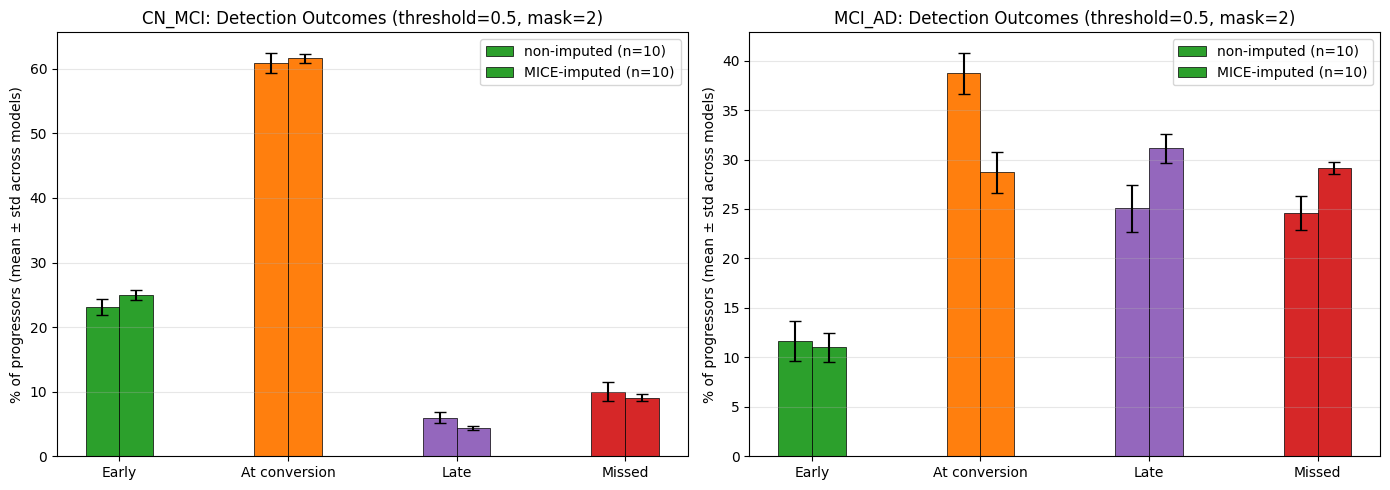

In [7]:
# ── Config ────────────────────────────────────────────────────────────────
THRESHOLD = 0.5
MASK_LENGTH = 2
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]

STATUS_ORDER = ["detected_early", "detected_at_conversion", "detected_late", "missed"]
STATUS_LABELS = ["Early", "At conversion", "Late", "Missed"]
COLORS = {"detected_early": "#2ca02c", "detected_at_conversion": "#ff7f0e",
          "detected_late": "#9467bd", "missed": "#d62728"}

# Convert to list in the order of STATUS_ORDER
status_colors = [COLORS[s] for s in STATUS_ORDER]

# ── Score every cached model ──
per_model_pct = {}  # {(imputation, cohort): DataFrame[model_key, early_pct, at_conv_pct, late_pct, missed_pct]}

for imp in IMPUTATIONS:
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        rows = []
        for model_key in sorted(os.listdir(cohort_dir)):
            model_dir = os.path.join(cohort_dir, model_key)
            prog_path = os.path.join(model_dir, 'lead_time_probabilities.csv')
            ctrl_path = os.path.join(model_dir, 'control_probabilities.csv')
            if not (os.path.exists(prog_path) and os.path.exists(ctrl_path)):
                continue

            prog_df = pd.read_csv(prog_path)
            ctrl_df = pd.read_csv(ctrl_path)
            for df in (prog_df, ctrl_df):
                df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
                df['Progression'] = df['Progression'].apply(_parse_list)

            res = analyze_run(prog_df, ctrl_df, THRESHOLD, MASK_LENGTH)
            n_prog = res['n_prog']
            if n_prog == 0:
                continue
            rows.append({
                'model_key': model_key,
                'early_pct':   res['n_early']   / n_prog * 100,
                'at_conv_pct': res['n_at_conv'] / n_prog * 100,
                'late_pct':    res['n_late']    / n_prog * 100,
                'missed_pct':  res['n_missed']  / n_prog * 100,
            })

        per_model_pct[(imp, cohort)] = pd.DataFrame(rows)


# ── Plot ──
bar_width = 0.2
x = np.arange(len(STATUS_LABELS))

fig, axes = plt.subplots(1, len(COHORTS), figsize=(7 * len(COHORTS), 5))
if len(COHORTS) == 1:
    axes = [axes]

for ax, cohort in zip(axes, COHORTS):
    for i, imp in enumerate(IMPUTATIONS):
        df = per_model_pct.get((imp, cohort))
        if df is None or df.empty:
            continue

        means = [df['early_pct'].mean(), df['at_conv_pct'].mean(),
                 df['late_pct'].mean(), df['missed_pct'].mean()]
        stds  = [df['early_pct'].std(), df['at_conv_pct'].std(),
                 df['late_pct'].std(), df['missed_pct'].std()]

        offset = (i - (len(IMPUTATIONS) - 1) / 2) * bar_width

        # Plot all four bars for this imputation group
        # The color is now assigned per status (same colour for all imputations)
        bars = ax.bar(x + offset, means, bar_width, yerr=stds, capsize=4,
                      label=f"{imp} (n={len(df)})",
                      color=status_colors,        # list of 4 colours
                      edgecolor='black', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(STATUS_LABELS)
    ax.set_ylabel("% of progressors (mean ± std across models)")
    ax.set_title(f"{cohort}: Detection Outcomes (threshold={THRESHOLD}, mask={MASK_LENGTH})")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("leadtime_detection_outcomes_averaged.png", dpi=300, bbox_inches='tight')
plt.show()

## Threshold × Mask-Length Grid (recomputed with corrected conversion-month logic)

Rebuilds the same sensitivity / specificity / mean-lead-time / false-alarm-rate vs. threshold (by mask length) charts as the earlier grid-search cell, but reads directly from the cached per-model probability CSVs and rescoring them with `analyze_run` (which uses the corrected `get_conversion_month` true-conversion logic) instead of re-fitting/re-running the models. Results are averaged across all 10 seeds/variants per cohort/imputation, matching the averaging approach used for the detection-outcome bar charts above.


Scoring non‑imputed – CN_MCI ( 10 models )...
Scoring non‑imputed – MCI_AD ( 10 models )...
Scoring MICE‑imputed – CN_MCI ( 10 models )...
Scoring MICE‑imputed – MCI_AD ( 10 models )...


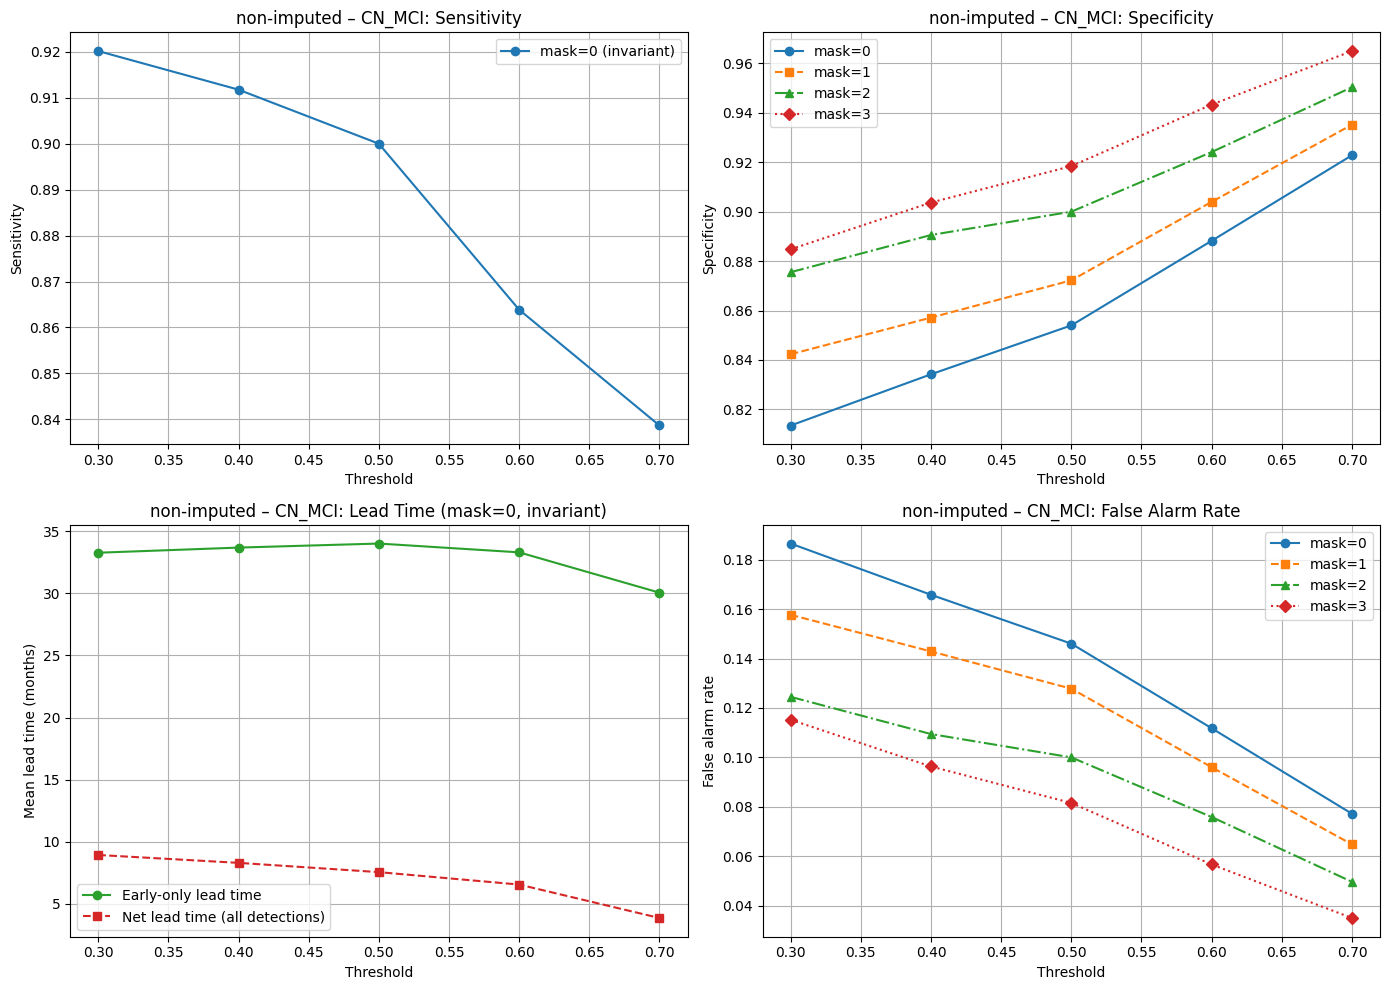

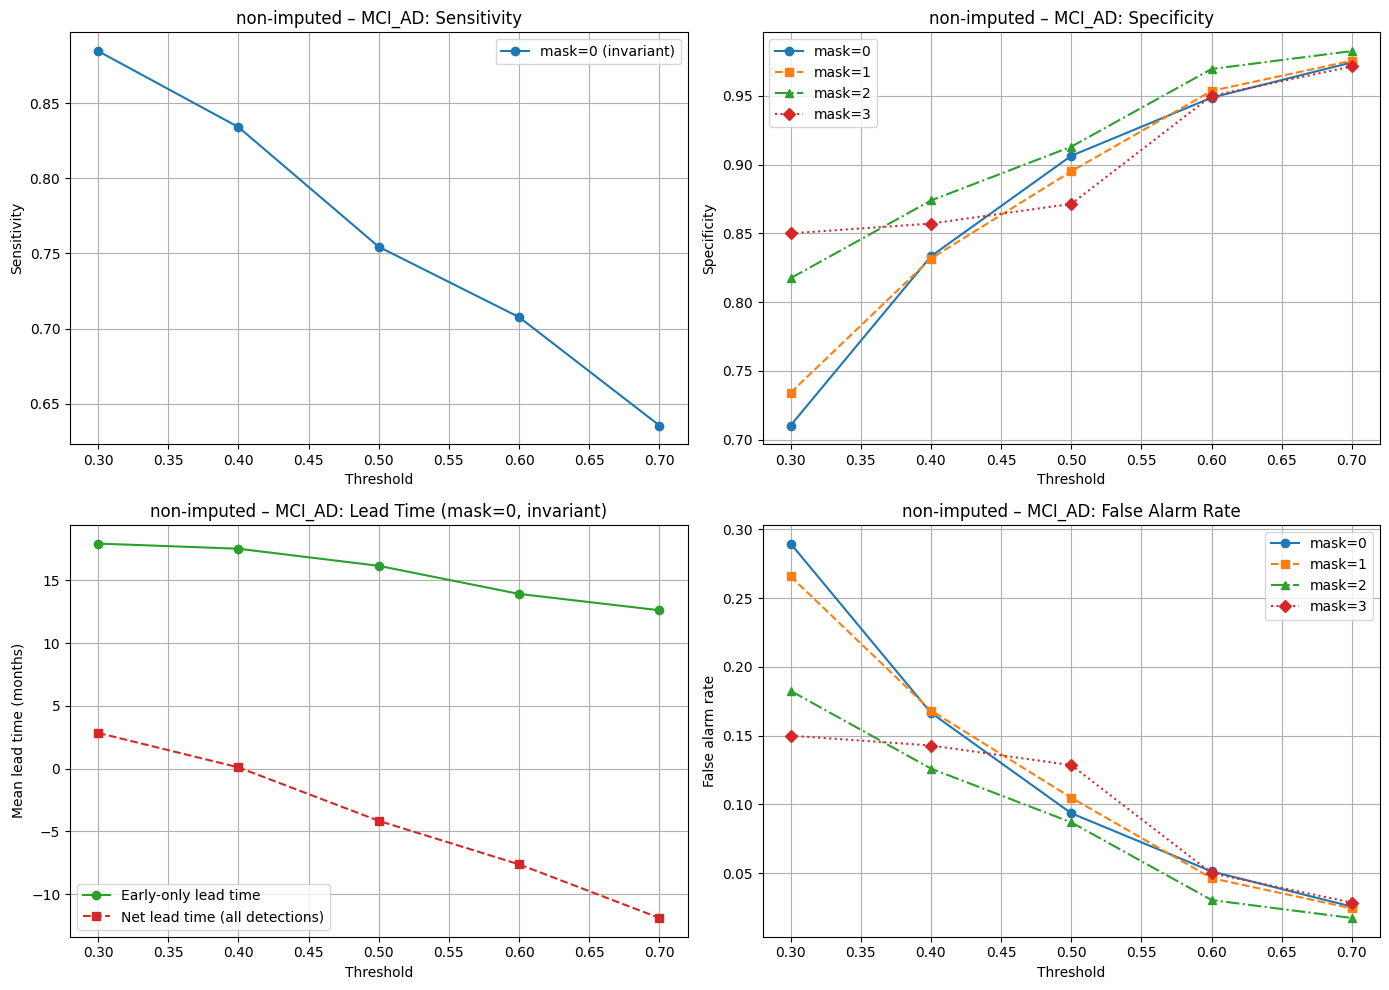

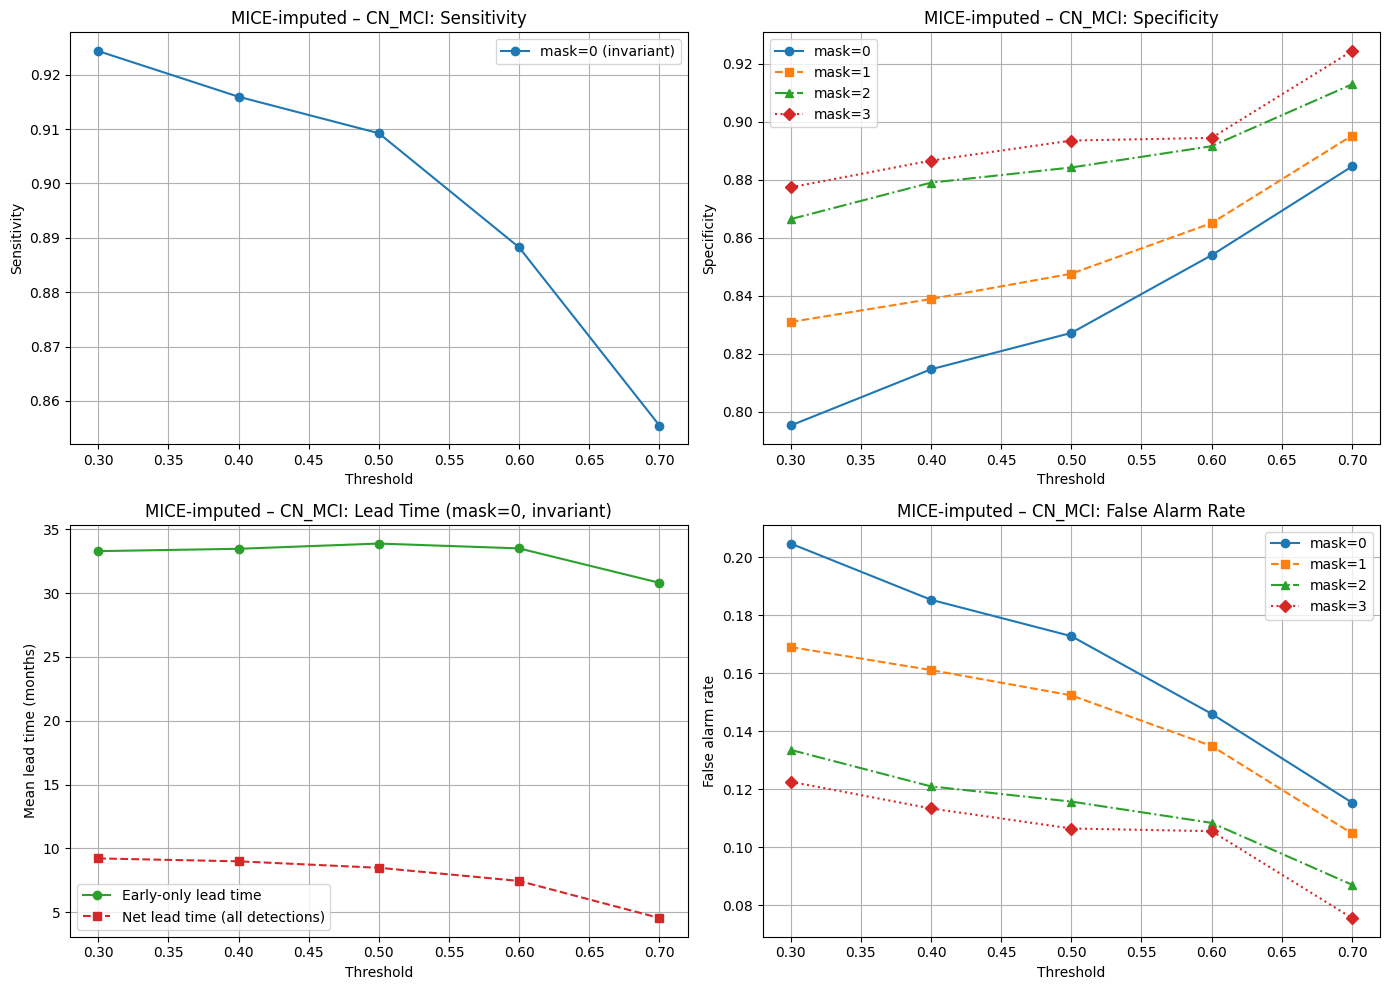

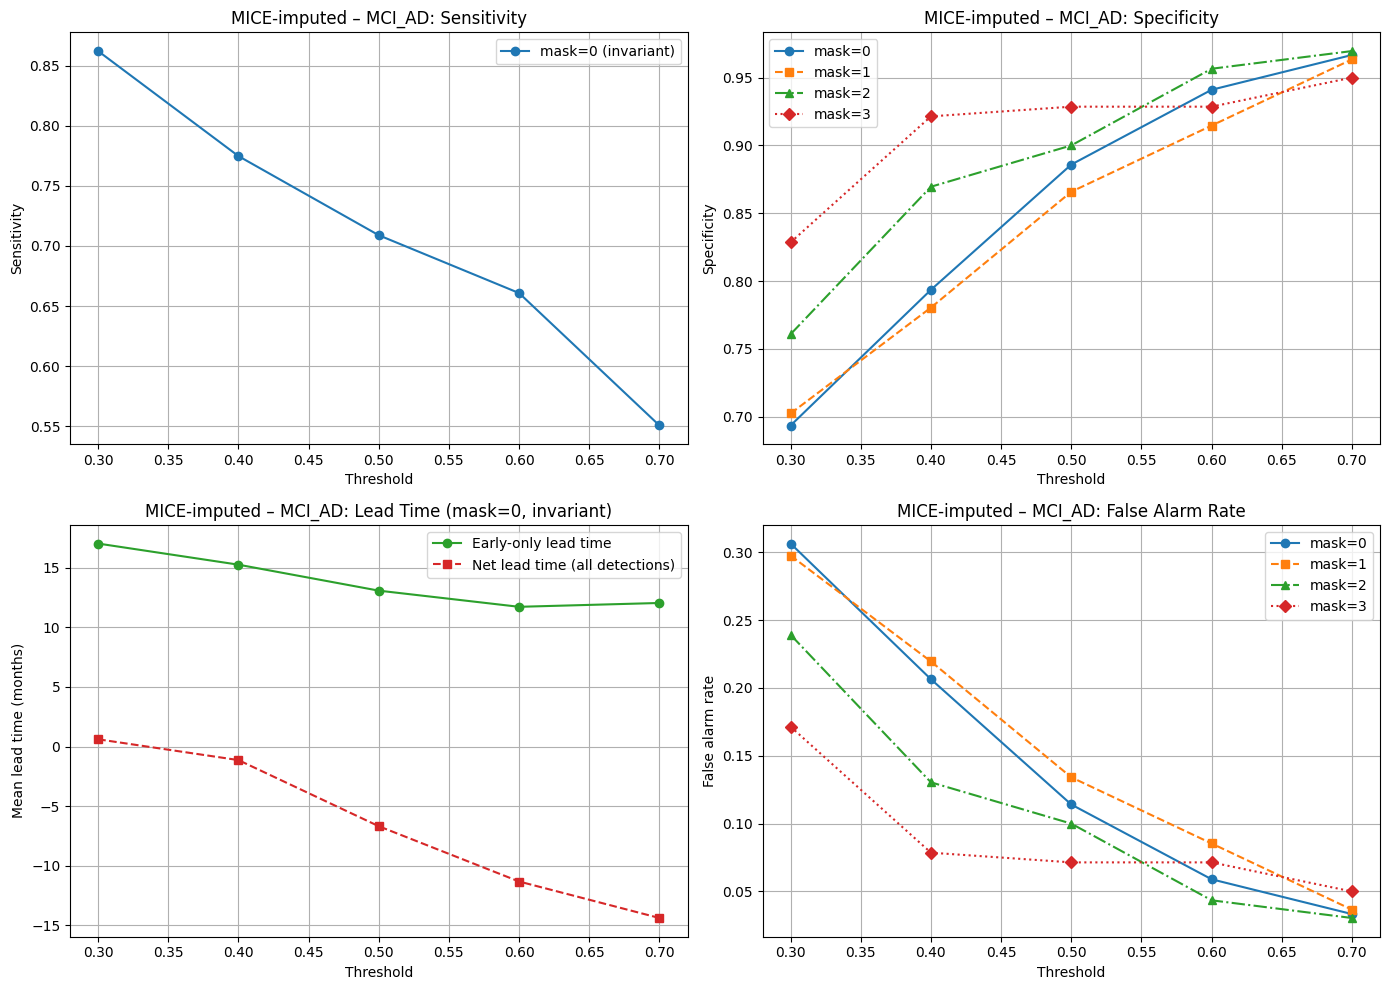

In [ ]:
# ── Reload leadtime module to ensure updated functions are used ──
import importlib
import leadtime
importlib.reload(leadtime)
from leadtime import run_grid, aggregate_grid, _parse_list, analyze_run

# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
mask_lengths = [0, 1, 2, 3]

# ── Rebuild the full threshold × mask_length grid from cached probability CSVs ────
all_results = {}  # {imputation: {cohort: agg_df}}

for imp in IMPUTATIONS:
    all_results[imp] = {}
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        prob_dict = {}
        for model_key in sorted(os.listdir(cohort_dir)):
            model_dir = os.path.join(cohort_dir, model_key)
            prog_path = os.path.join(model_dir, 'lead_time_probabilities.csv')
            ctrl_path = os.path.join(model_dir, 'control_probabilities.csv')
            if not (os.path.exists(prog_path) and os.path.exists(ctrl_path)):
                continue

            prog_df = pd.read_csv(prog_path)
            ctrl_df = pd.read_csv(ctrl_path)
            for df in (prog_df, ctrl_df):
                df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
                df['Progression'] = df['Progression'].apply(_parse_list)
            prob_dict[model_key] = {'prog': prog_df, 'ctrl': ctrl_df}

        print(f"Scoring {imp} – {cohort} ( {len(prob_dict)} models )...")
        df_grid = run_grid(prob_dict, thresholds, mask_lengths)
        agg_df = aggregate_grid(df_grid)          # now includes n_late, n_at_conv, mean_net_lead_time, etc.
        all_results[imp][cohort] = agg_df
        agg_df.to_csv(f"leadtime_agg_{imp}_{cohort}.csv", index=False)


# ── Plotting: Sensitivity & lead time only for mask=0 (invariant); Specificity & FAR with all masks ──
LINESTYLES = {0: '-', 1: '--', 2: '-.', 3: ':'}
MARKERS = {0: 'o', 1: 's', 2: '^', 3: 'D'}

for imp, cohorts in all_results.items():
    for cohort, agg_df in cohorts.items():
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # 1. Sensitivity vs threshold – only mask=0 (invariant)
        ax = axes[0, 0]
        sub = agg_df[agg_df['mask_length'] == 0]
        ax.plot(sub['threshold'], sub['sensitivity_mean'],
                linestyle='-', marker='o', color='#1f77b4', label='mask=0 (invariant)')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Sensitivity')
        ax.set_title(f'{imp} – {cohort}: Sensitivity')
        ax.legend()
        ax.grid(True)

        # 2. Specificity vs threshold – all masks
        ax = axes[0, 1]
        for mask in mask_lengths:
            sub = agg_df[agg_df['mask_length'] == mask]
            ax.plot(sub['threshold'], sub['specificity_mean'],
                    linestyle=LINESTYLES[mask], marker=MARKERS[mask], label=f'mask={mask}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Specificity')
        ax.set_title(f'{imp} – {cohort}: Specificity')
        ax.legend()
        ax.grid(True)

        # 3. Lead time vs threshold – only mask=0, showing both early-only and net
        ax = axes[1, 0]
        sub = agg_df[agg_df['mask_length'] == 0]
        # Early-only lead time (positive)
        ax.plot(sub['threshold'], sub['mean_lead_time_mean'],
                linestyle='-', marker='o', color='#2ca02c', label='Early-only lead time')
        # Net lead time (including late detections, may be negative)
        ax.plot(sub['threshold'], sub['mean_net_lead_time_mean'],
                linestyle='--', marker='s', color='#d62728', label='Net lead time (all detections)')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Mean lead time (months)')
        ax.set_title(f'{imp} – {cohort}: Lead Time (mask=0, invariant)')
        ax.legend()
        ax.grid(True)

        # 4. False alarm rate vs threshold – all masks
        ax = axes[1, 1]
        for mask in mask_lengths:
            sub = agg_df[agg_df['mask_length'] == mask]
            ax.plot(sub['threshold'], sub['false_alarm_rate_mean'],
                    linestyle=LINESTYLES[mask], marker=MARKERS[mask], label=f'mask={mask}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('False alarm rate')
        ax.set_title(f'{imp} – {cohort}: False Alarm Rate')
        ax.legend()
        ax.grid(True)

        plt.tight_layout()
        plt.savefig(f"leadtime_plots_{imp}_{cohort}.png", dpi=300, bbox_inches='tight')
        plt.show()


===== non‑imputed – CN_MCI: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.3 | 0.920 (0.916-0.924) | 0.813 (0.808-0.819) | 0.528 (0.521-0.534) | 0.978 (0.977-0.979) | 0.833 (0.829-0.837) | 0.671 (0.666-0.675) | 0.187 (0.181-0.192) | 33.283 (32.840-33.726) | 8.920 (8.768-9.071)
0.4 | 0.912 (0.908-0.916) | 0.834 (0.829-0.840) | 0.555 (0.547-0.562) | 0.977 (0.976-0.978) | 0.849 (0.845-0.852) | 0.690 (0.685-0.694) | 0.166 (0.160-0.171) | 33.697 (33.139-34.255) | 8.285 (7.972-8.597)
0.5 | 0.900 (0.890-0.910) | 0.854 (0.844-0.864) | 0.583 (0.568-0.598) | 0.974 (0.972-0.977) | 0.862 (0.855-0.869) | 0.707 (0.698-0.717) | 0.146 (0.136-0.156) | 34.023 (33.409-34.636) | 7.537 (7.234-7.841)
0.6 | 0.864 (0.853-0.875) | 0.888 (0.879-0.897) | 0.637 (0.619-0.656) | 0.967 (0.964-0.969) | 0.884 (0.877-0.890) | 0.733 (0.722-0.744) | 0.112 (0

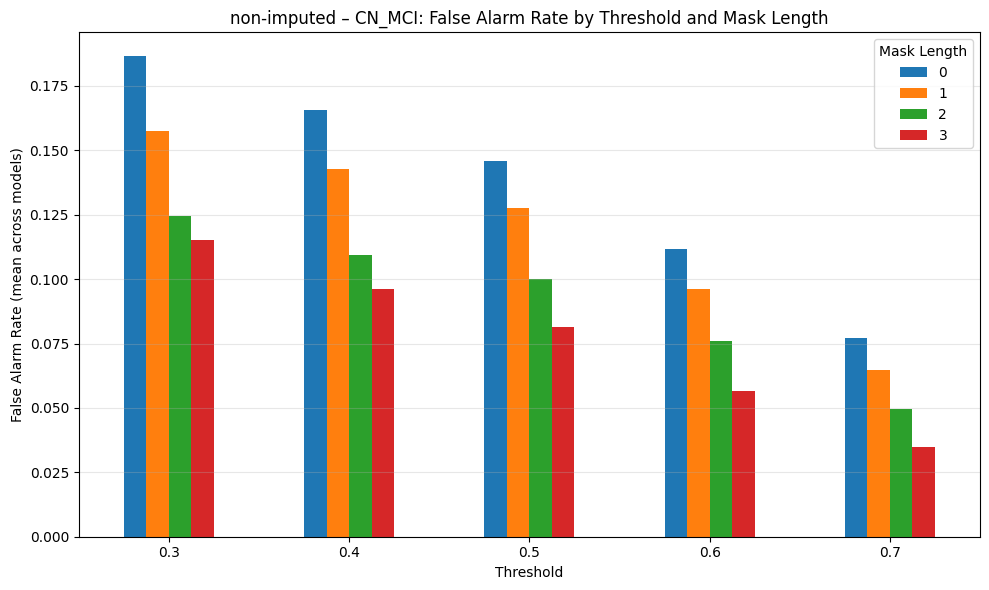


===== non‑imputed – MCI_AD: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.3 | 0.885 (0.874-0.896) | 0.710 (0.696-0.724) | 0.756 (0.746-0.765) | 0.859 (0.847-0.871) | 0.798 (0.789-0.807) | 0.815 (0.807-0.823) | 0.290 (0.276-0.304) | 17.935 (17.650-18.220) | 2.852 (2.446-3.258)
0.4 | 0.834 (0.825-0.843) | 0.833 (0.820-0.846) | 0.835 (0.824-0.847) | 0.832 (0.824-0.841) | 0.834 (0.825-0.843) | 0.835 (0.826-0.843) | 0.167 (0.154-0.180) | 17.523 (17.187-17.859) | 0.105 (-0.437-0.647)
0.5 | 0.754 (0.742-0.767) | 0.906 (0.899-0.914) | 0.891 (0.883-0.899) | 0.785 (0.776-0.794) | 0.830 (0.822-0.838) | 0.817 (0.808-0.826) | 0.094 (0.086-0.101) | 16.161 (15.258-17.065) | -4.154 (-4.847--3.461)
0.6 | 0.708 (0.695-0.720) | 0.949 (0.940-0.957) | 0.933 (0.924-0.943) | 0.762 (0.755-0.770) | 0.827 (0.821-0.834) | 0.805 (0.797-0.813) | 0.05

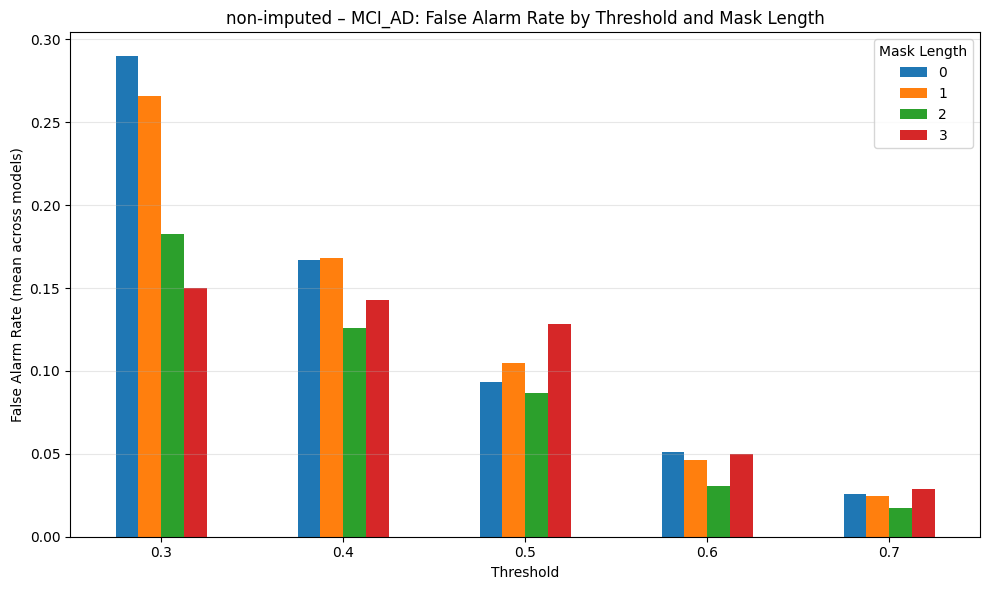


===== MICE‑imputed – CN_MCI: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.3 | 0.924 (0.922-0.927) | 0.795 (0.792-0.799) | 0.505 (0.501-0.509) | 0.979 (0.978-0.980) | 0.819 (0.816-0.822) | 0.653 (0.650-0.657) | 0.205 (0.201-0.208) | 33.287 (33.090-33.483) | 9.215 (9.106-9.323)
0.4 | 0.916 (0.916-0.916) | 0.815 (0.813-0.816) | 0.528 (0.526-0.530) | 0.977 (0.977-0.977) | 0.833 (0.832-0.835) | 0.670 (0.668-0.672) | 0.185 (0.184-0.187) | 33.470 (33.389-33.551) | 8.986 (8.916-9.055)
0.5 | 0.909 (0.905-0.913) | 0.827 (0.825-0.829) | 0.543 (0.541-0.546) | 0.976 (0.975-0.977) | 0.842 (0.841-0.844) | 0.680 (0.678-0.682) | 0.173 (0.171-0.175) | 33.881 (33.478-34.284) | 8.480 (8.358-8.602)
0.6 | 0.888 (0.884-0.892) | 0.854 (0.848-0.860) | 0.579 (0.571-0.588) | 0.971 (0.970-0.972) | 0.860 (0.856-0.864) | 0.701 (0.696-0.707) | 0.146 (

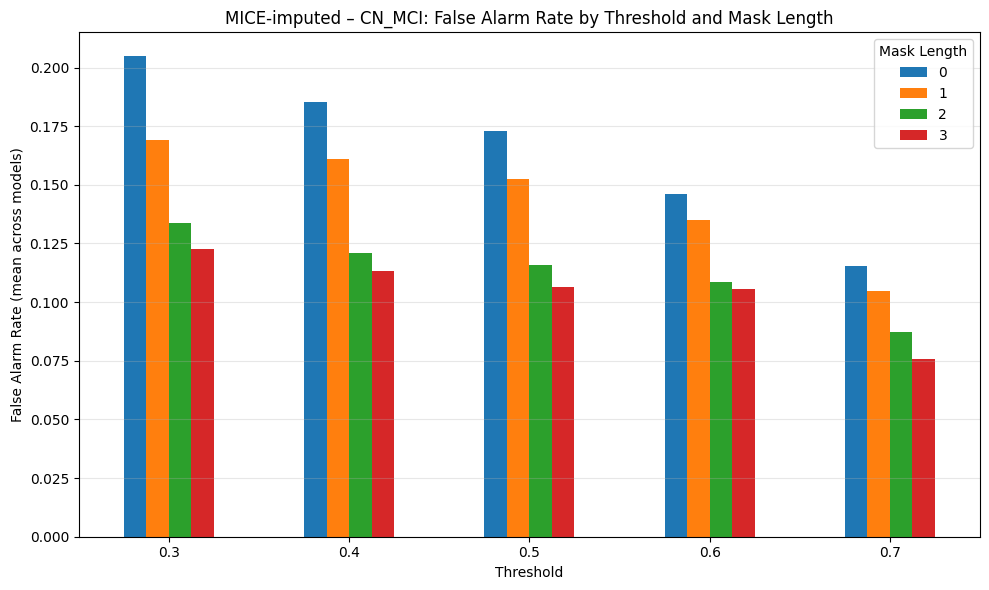


===== MICE‑imputed – MCI_AD: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.3 | 0.862 (0.857-0.867) | 0.694 (0.676-0.711) | 0.741 (0.730-0.751) | 0.832 (0.827-0.838) | 0.778 (0.770-0.787) | 0.797 (0.790-0.803) | 0.306 (0.289-0.324) | 17.037 (16.671-17.403) | 0.610 (0.402-0.818)
0.4 | 0.775 (0.764-0.786) | 0.794 (0.786-0.802) | 0.792 (0.786-0.798) | 0.777 (0.769-0.785) | 0.784 (0.779-0.790) | 0.783 (0.777-0.789) | 0.206 (0.198-0.214) | 15.264 (14.700-15.828) | -1.136 (-1.587--0.686)
0.5 | 0.709 (0.705-0.713) | 0.886 (0.873-0.898) | 0.863 (0.850-0.876) | 0.750 (0.747-0.753) | 0.797 (0.791-0.803) | 0.778 (0.773-0.784) | 0.114 (0.102-0.127) | 13.084 (12.473-13.696) | -6.686 (-7.307--6.065)
0.6 | 0.661 (0.654-0.668) | 0.941 (0.935-0.947) | 0.919 (0.911-0.927) | 0.733 (0.728-0.737) | 0.800 (0.795-0.805) | 0.769 (0.762-0.775) | 0

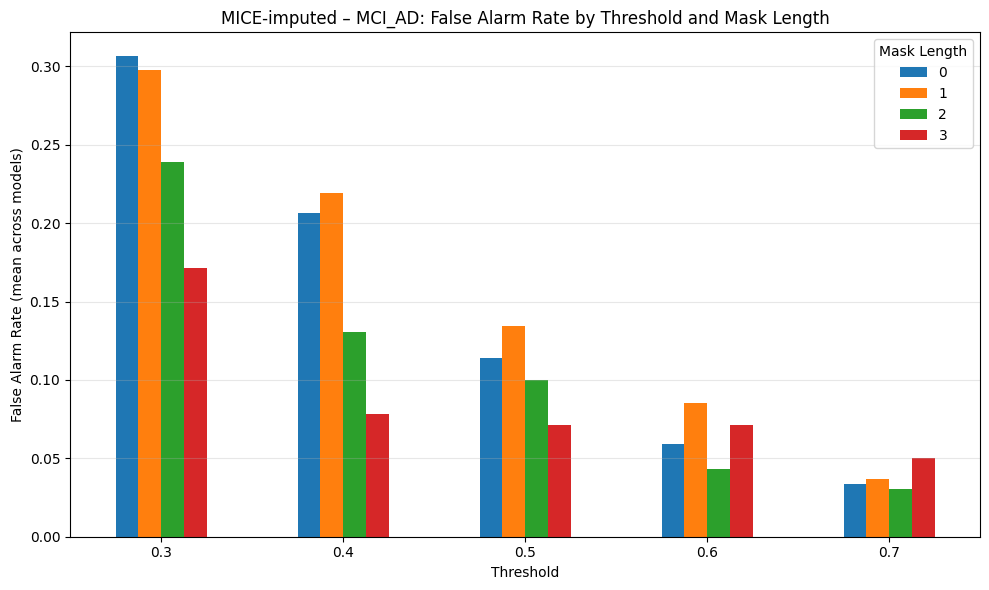

All summary statistics and bar charts generated.


In [9]:
# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
MASK_LENGTHS = [0, 1, 2, 3]

# We'll collect per‑model raw results for each (imputation, cohort)
all_raw_dfs = {}

for imp in IMPUTATIONS:
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        prob_dict = {}
        for model_key in sorted(os.listdir(cohort_dir)):
            model_dir = os.path.join(cohort_dir, model_key)
            prog_path = os.path.join(model_dir, 'lead_time_probabilities.csv')
            ctrl_path = os.path.join(model_dir, 'control_probabilities.csv')
            if not (os.path.exists(prog_path) and os.path.exists(ctrl_path)):
                continue
            prog_df = pd.read_csv(prog_path)
            ctrl_df = pd.read_csv(ctrl_path)
            for df in (prog_df, ctrl_df):
                df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
                df['Progression'] = df['Progression'].apply(_parse_list)
            prob_dict[model_key] = {'prog': prog_df, 'ctrl': ctrl_df}

        if not prob_dict:
            continue

        # Run grid to get per‑model metrics (now includes mean_net_lead_time)
        df_grid = run_grid(prob_dict, THRESHOLDS, MASK_LENGTHS)
        all_raw_dfs[(imp, cohort)] = df_grid

# ── Compute additional metrics per row ──
def add_metrics(df):
    # df has columns: model_key, threshold, mask_length, n_prog, n_detected, n_missed,
    # n_ctrl, n_false_alarm, sensitivity, specificity, mean_lead_time, mean_net_lead_time,
    # median_lead_time, median_net_lead_time, false_alarm_rate, plus counts
    df = df.copy()
    TP = df['n_detected']
    FN = df['n_missed']
    FP = df['n_false_alarm']
    TN = df['n_ctrl'] - FP

    df['PPV'] = TP / (TP + FP)
    df['NPV'] = TN / (TN + FN)
    df['accuracy'] = (TP + TN) / (df['n_prog'] + df['n_ctrl'])
    df['f1'] = 2 * (df['PPV'] * df['sensitivity']) / (df['PPV'] + df['sensitivity'])
    return df

# ── Aggregate and produce tables with 95% CI ──
# Include both early-only lead time and net lead time in the table
metrics_to_agg = ['sensitivity', 'specificity', 'PPV', 'NPV', 'accuracy', 'f1',
                  'false_alarm_rate', 'mean_lead_time', 'mean_net_lead_time']

for (imp, cohort), df_raw in all_raw_dfs.items():
    df_raw = add_metrics(df_raw)

    # Group by threshold and mask_length to compute mean, std, CI
    grouped = df_raw.groupby(['threshold', 'mask_length'])
    summary_rows = []
    for (thr, mask), group in grouped:
        row = {'threshold': thr, 'mask_length': mask}
        for m in metrics_to_agg:
            vals = group[m].dropna().values
            if len(vals) > 1:
                mean, lo, hi, std = mean_ci(vals)
                row[f'{m}_mean'] = mean
                row[f'{m}_ci_lower'] = lo
                row[f'{m}_ci_upper'] = hi
            elif len(vals) == 1:
                row[f'{m}_mean'] = vals[0]
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
            else:
                row[f'{m}_mean'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows)

    # Print a nice table for each mask_length
    print(f"\n===== {imp} – {cohort}: Summary metrics by threshold =====")
    # Note: Sensitivity, mean_lead_time, and mean_net_lead_time are invariant to mask_length
    # (because mask is not applied to progressors). They will be identical for all masks,
    # which serves as a sanity check.
    for mask in MASK_LENGTHS:
        sub = summary_df[summary_df['mask_length'] == mask].sort_values('threshold')
        if sub.empty:
            continue
        print(f"\nMask length = {mask}")
        # Extended header to include Net Lead
        header = ("Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | "
                  "Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)")
        print(header)
        for _, row in sub.iterrows():
            def fmt(m):
                return f"{row[f'{m}_mean']:.3f} ({row[f'{m}_ci_lower']:.3f}-{row[f'{m}_ci_upper']:.3f})" if not np.isnan(row[f'{m}_ci_lower']) else f"{row[f'{m}_mean']:.3f}"
            print(f"{row['threshold']:.1f} | {fmt('sensitivity')} | {fmt('specificity')} | "
                  f"{fmt('PPV')} | {fmt('NPV')} | {fmt('accuracy')} | {fmt('f1')} | "
                  f"{fmt('false_alarm_rate')} | {fmt('mean_lead_time')} | {fmt('mean_net_lead_time')}")

    # Bar chart for false alarm rate across thresholds, grouped by mask length
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot = summary_df.pivot(index='threshold', columns='mask_length', values='false_alarm_rate_mean')
    pivot.plot(kind='bar', ax=ax, yerr=None, capsize=4, rot=0)
    ax.set_title(f"{imp} – {cohort}: False Alarm Rate by Threshold and Mask Length")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("False Alarm Rate (mean across models)")
    ax.legend(title="Mask Length")
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("All summary statistics and bar charts generated.")


===== non‑imputed – CN_MCI: Dynamic mask (percentile=5%) =====
Threshold | Mask_len (mean±std) | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.3 | 1.0±0.0 | 0.920 (0.916-0.924) | 0.842 (0.837-0.848) | 0.648 (0.640-0.655) | 0.971 (0.970-0.972) | 0.861 (0.857-0.865) | 0.760 (0.756-0.765) | 0.158 (0.152-0.163) | 33.283 (32.840-33.726) | 8.920 (8.768-9.071)
0.4 | 1.0±0.0 | 0.912 (0.908-0.916) | 0.857 (0.852-0.862) | 0.668 (0.661-0.674) | 0.969 (0.967-0.970) | 0.870 (0.867-0.873) | 0.771 (0.767-0.775) | 0.143 (0.138-0.148) | 33.697 (33.139-34.255) | 8.285 (7.972-8.597)
0.5 | 1.0±0.0 | 0.900 (0.890-0.910) | 0.872 (0.864-0.880) | 0.690 (0.678-0.702) | 0.965 (0.962-0.968) | 0.879 (0.875-0.883) | 0.781 (0.776-0.786) | 0.128 (0.120-0.136) | 34.023 (33.409-34.636) | 7.537 (7.234-7.841)
0.6 | 1.0±0.0 | 0.864 (0.853-0.875) | 0.904 (0.894-0.914) | 0.740 (0.721-0.759) | 0.955 (0.951-0.958) | 0.894 (

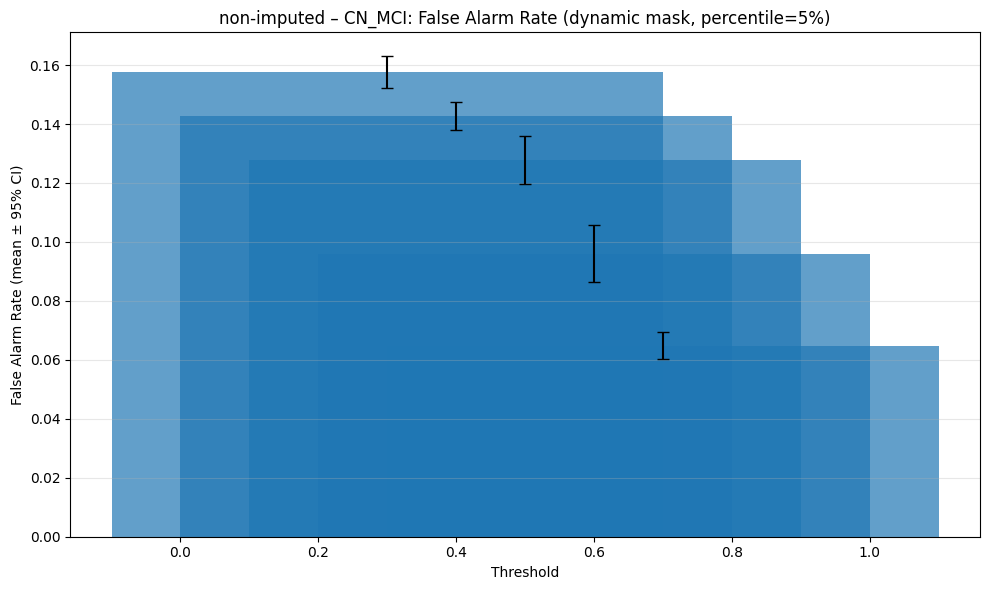

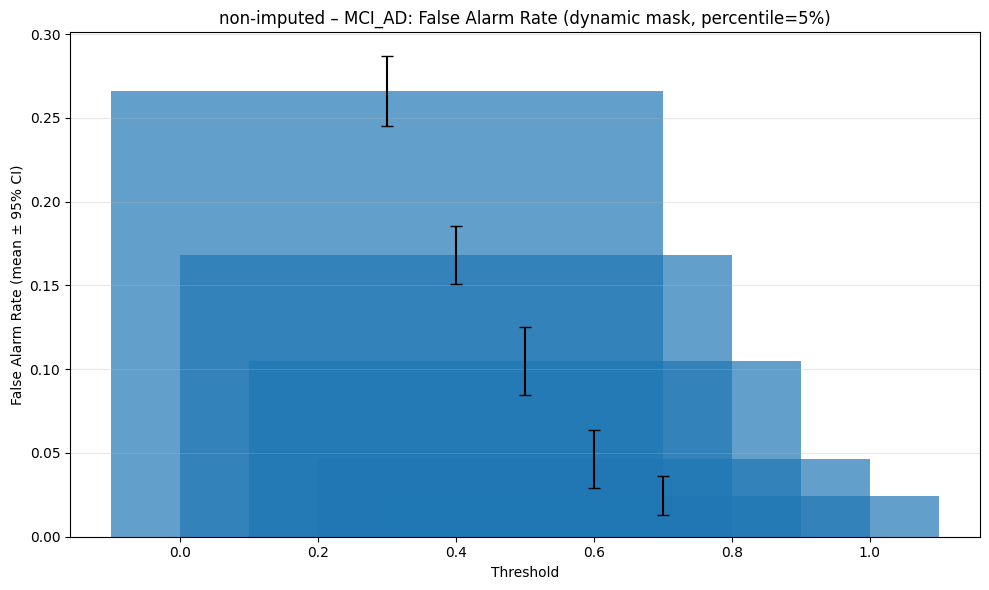

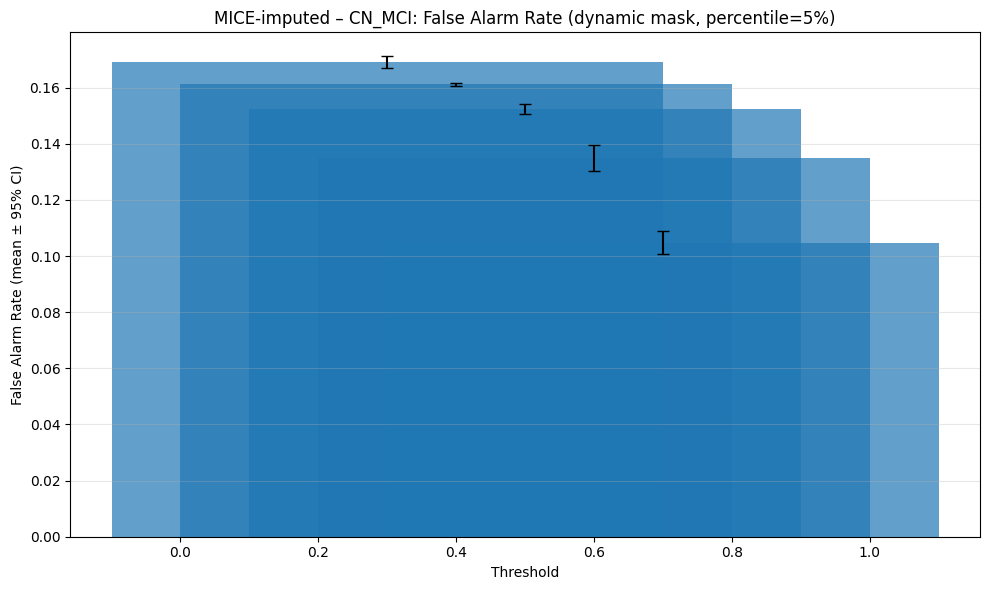

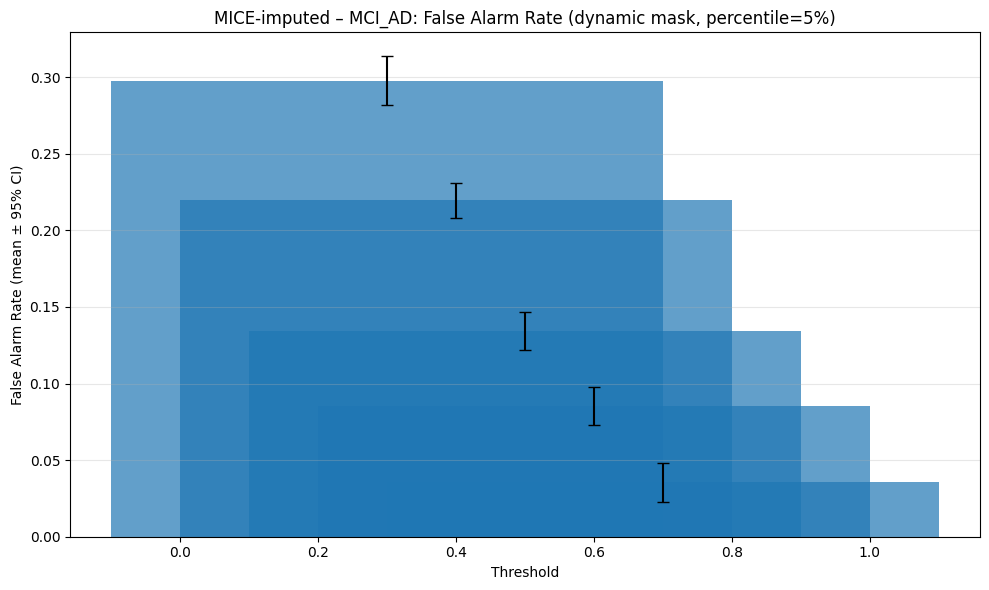

Dynamic mask analysis complete.


In [ ]:
# =============================================================================
# Dynamic mask selection based on lead‑time distribution
# =============================================================================

# ── Reload leadtime module to ensure updated functions are used ──
import importlib
import leadtime
importlib.reload(leadtime)
from leadtime import run_grid, _parse_list, mean_ci, analyze_run, get_conversion_month

# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
LEAD_TIME_PERCENTILE = 0.95   # 5th percentile of lead times -> exclude shortest 5%

# We'll collect per‑model results for each (imputation, cohort) with dynamic mask
dynamic_results = {}  # (imputation, cohort) -> list of rows per model and threshold

for imp in IMPUTATIONS:
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        # Load all model probability dicts
        prob_dict = {}
        for model_key in sorted(os.listdir(cohort_dir)):
            model_dir = os.path.join(cohort_dir, model_key)
            prog_path = os.path.join(model_dir, 'lead_time_probabilities.csv')
            ctrl_path = os.path.join(model_dir, 'control_probabilities.csv')
            if not (os.path.exists(prog_path) and os.path.exists(ctrl_path)):
                continue
            prog_df = pd.read_csv(prog_path)
            ctrl_df = pd.read_csv(ctrl_path)
            for df in (prog_df, ctrl_df):
                df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
                df['Progression'] = df['Progression'].apply(_parse_list)
            prob_dict[model_key] = {'prog': prog_df, 'ctrl': ctrl_df}

        if not prob_dict:
            continue

        rows = []
        for model_key, dfs in prob_dict.items():
            prog_df = dfs['prog']
            ctrl_df = dfs['ctrl']
            pred_cols = sorted([c for c in prog_df.columns if c.isdigit()], key=int)

            for thr in THRESHOLDS:
                # ---- Compute early lead times with mask_length=0 ----
                lead_times = []
                for _, row in prog_df.iterrows():
                    months = row['months_since_baseline']
                    progression = row['Progression']
                    true_conv_month = get_conversion_month(progression, months)
                    if true_conv_month is None:
                        continue
                    n_visits = len(months)
                    max_trunc = n_visits - 2  # mask=0
                    probs = []
                    for c in pred_cols:
                        if int(c) > max_trunc:
                            continue
                        if pd.notna(row[c]):
                            probs.append(row[c])
                    alarm_idx = None
                    for i, p in enumerate(probs):
                        if p >= thr:
                            alarm_idx = i
                            break
                    if alarm_idx is not None:
                        alarm_month = months[alarm_idx + 1]
                        lead = true_conv_month - alarm_month
                        if lead > 0:  # early detection
                            lead_times.append(lead)

                if len(lead_times) == 0:
                    mask_len = 0
                else:
                    target_lead = np.percentile(lead_times, LEAD_TIME_PERCENTILE * 100)
                    # # Count visits in last target_lead months for all subjects (prog + ctrl)
                    # all_subjects = list(prog_df.iterrows()) + list(ctrl_df.iterrows())
                    # visit_counts = []
                    # for _, row in all_subjects:
                    #     months = row['months_since_baseline']
                    #     last = months[-1]
                    #     count = sum(1 for m in months if m >= last - target_lead)
                    #     visit_counts.append(count)
                    # mask_len = int(np.median(visit_counts))

                    mask_len = int(round(target_lead / 15.9)) # divide by average visit interval 15.9 months
                    mask_len = max(0, mask_len)

                # Now run analyze_run with the dynamic mask (applied only to controls)
                res = analyze_run(prog_df, ctrl_df, thr, mask_len)
                rows.append({
                    'model_key': model_key,
                    'threshold': thr,
                    'mask_length': mask_len,
                    **res
                })

        # Convert to DataFrame
        df_dyn = pd.DataFrame(rows)
        dynamic_results[(imp, cohort)] = df_dyn

# ── Compute additional metrics (PPV, NPV, accuracy, F1) per model ──
def add_metrics(df):
    df = df.copy()
    TP = df['n_detected']
    FN = df['n_missed']
    FP = df['n_false_alarm']
    TN = df['n_ctrl'] - FP
    df['PPV'] = TP / (TP + FP)
    df['NPV'] = TN / (TN + FN)
    df['accuracy'] = (TP + TN) / (df['n_prog'] + df['n_ctrl'])
    df['f1'] = 2 * (df['PPV'] * df['sensitivity']) / (df['PPV'] + df['sensitivity'])
    return df

dynamic_with_metrics = {}
for (imp, cohort), df in dynamic_results.items():
    dynamic_with_metrics[(imp, cohort)] = add_metrics(df)

# ── Aggregate dynamic results with all metrics, including net lead time ──
metrics_all = ['sensitivity', 'specificity', 'PPV', 'NPV', 'accuracy', 'f1',
               'false_alarm_rate', 'mean_lead_time', 'mean_net_lead_time']
agg_dynamic_full = {}
for (imp, cohort), df in dynamic_with_metrics.items():
    summary_rows = []
    for thr in THRESHOLDS:
        sub = df[df['threshold'] == thr]
        if sub.empty:
            continue
        row = {'threshold': thr}
        mask_vals = sub['mask_length'].values
        row['mask_length_mean'] = np.mean(mask_vals)
        row['mask_length_std'] = np.std(mask_vals) if len(mask_vals) > 1 else np.nan
        for m in metrics_all:
            vals = sub[m].dropna().values
            if len(vals) > 1:
                mean, lo, hi, std = mean_ci(vals)
                row[f'{m}_mean'] = mean
                row[f'{m}_ci_lower'] = lo
                row[f'{m}_ci_upper'] = hi
            elif len(vals) == 1:
                row[f'{m}_mean'] = vals[0]
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
            else:
                row[f'{m}_mean'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
        summary_rows.append(row)
    agg_dynamic_full[(imp, cohort)] = pd.DataFrame(summary_rows)

# ── Print full tables with both early and net lead times ──
for (imp, cohort), df in agg_dynamic_full.items():
    print(f"\n===== {imp} – {cohort}: Dynamic mask (percentile={LEAD_TIME_PERCENTILE:.0%}) =====")
    header = ("Threshold | Mask_len (mean±std) | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | "
              "Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)")
    print(header)
    for _, row in df.iterrows():
        def fmt(m):
            return f"{row[f'{m}_mean']:.3f} ({row[f'{m}_ci_lower']:.3f}-{row[f'{m}_ci_upper']:.3f})" if not np.isnan(row[f'{m}_ci_lower']) else f"{row[f'{m}_mean']:.3f}"
        mask_str = f"{row['mask_length_mean']:.1f}±{row['mask_length_std']:.1f}" if not np.isnan(row['mask_length_std']) else f"{row['mask_length_mean']:.1f}"
        print(f"{row['threshold']:.1f} | {mask_str} | {fmt('sensitivity')} | {fmt('specificity')} | "
              f"{fmt('PPV')} | {fmt('NPV')} | {fmt('accuracy')} | {fmt('f1')} | "
              f"{fmt('false_alarm_rate')} | {fmt('mean_lead_time')} | {fmt('mean_net_lead_time')}")

# ── Bar chart for false alarm rate from dynamic mask results ──
for (imp, cohort), df in agg_dynamic_full.items():
    if df.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(df['threshold'].astype(str), df['false_alarm_rate_mean'],
           yerr=[df['false_alarm_rate_mean'] - df['false_alarm_rate_ci_lower'],
                 df['false_alarm_rate_ci_upper'] - df['false_alarm_rate_mean']],
           capsize=4, alpha=0.7)
    ax.set_title(f"{imp} – {cohort}: False Alarm Rate (dynamic mask, percentile={LEAD_TIME_PERCENTILE:.0%})")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("False Alarm Rate (mean ± 95% CI)")
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Dynamic mask analysis complete.")

In [11]:
# =============================================================================
# Save summary statistics to CSV files
# =============================================================================


# Ensure the output directory exists
OUTPUT_DIR = "lead_time results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Fixed mask summary (from the first additional cell) ──
# The fixed mask summary DataFrames are stored in `summary_df` (or we can re‑create them if needed).
# However, in the first additional cell we used `summary_df` but it was overwritten per (imp, cohort).
# We need to store them in a dict while generating, but we can also recompute quickly from the raw grid results.

# We already have `all_raw_dfs` from the first cell, and we computed `summary_df` inside the loop.
# To be safe, we'll re‑run the aggregation for fixed mask and save.

# Re‑use the logic from the first additional cell, but we'll just save the DataFrames.
fixed_summaries = {}
for (imp, cohort), df_raw in all_raw_dfs.items():
    df_raw = add_metrics(df_raw)  # ensure metrics are added
    grouped = df_raw.groupby(['threshold', 'mask_length'])
    summary_rows = []
    for (thr, mask), group in grouped:
        row = {'threshold': thr, 'mask_length': mask}
        for m in metrics_to_agg:
            vals = group[m].dropna().values
            if len(vals) > 1:
                mean, lo, hi, std = mean_ci(vals)
                row[f'{m}_mean'] = mean
                row[f'{m}_ci_lower'] = lo
                row[f'{m}_ci_upper'] = hi
            elif len(vals) == 1:
                row[f'{m}_mean'] = vals[0]
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
            else:
                row[f'{m}_mean'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
        summary_rows.append(row)
    fixed_summaries[(imp, cohort)] = pd.DataFrame(summary_rows)

# Save fixed mask summaries
for (imp, cohort), df in fixed_summaries.items():
    if not df.empty:
        out_path = os.path.join(OUTPUT_DIR, f"fixed_mask_summary_{imp}_{cohort}.csv")
        df.to_csv(out_path, index=False)
        print(f"Saved fixed mask summary to {out_path}")

# ── 2. Dynamic mask summary (from the second additional cell) ──
# We have `agg_dynamic_full` dict from the dynamic mask cell.
# Save each DataFrame.
for (imp, cohort), df in agg_dynamic_full.items():
    if not df.empty:
        out_path = os.path.join(OUTPUT_DIR, f"dynamic_mask_summary_{imp}_{cohort}_p{int(LEAD_TIME_PERCENTILE*100)}.csv")
        df.to_csv(out_path, index=False)
        print(f"Saved dynamic mask summary to {out_path}")

# ── 3. Optional: save the raw per‑model results for fixed and dynamic grids ──
# Fixed raw results are in `all_raw_dfs`; we can save them as well.
for (imp, cohort), df in all_raw_dfs.items():
    out_path = os.path.join(OUTPUT_DIR, f"fixed_mask_raw_{imp}_{cohort}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved fixed mask raw results to {out_path}")

# Dynamic raw results are in `dynamic_results`.
for (imp, cohort), df in dynamic_results.items():
    out_path = os.path.join(OUTPUT_DIR, f"dynamic_mask_raw_{imp}_{cohort}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved dynamic mask raw results to {out_path}")

print("\nAll summary and raw data files have been saved to the 'lead_time results' directory.")

Saved fixed mask summary to lead_time results/fixed_mask_summary_non‑imputed_CN_MCI.csv
Saved fixed mask summary to lead_time results/fixed_mask_summary_non‑imputed_MCI_AD.csv
Saved fixed mask summary to lead_time results/fixed_mask_summary_MICE‑imputed_CN_MCI.csv
Saved fixed mask summary to lead_time results/fixed_mask_summary_MICE‑imputed_MCI_AD.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_non‑imputed_CN_MCI_p5.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_non‑imputed_MCI_AD_p5.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_MICE‑imputed_CN_MCI_p5.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_MICE‑imputed_MCI_AD_p5.csv
Saved fixed mask raw results to lead_time results/fixed_mask_raw_non‑imputed_CN_MCI.csv
Saved fixed mask raw results to lead_time results/fixed_mask_raw_non‑imputed_MCI_AD.csv
Saved fixed mask raw results to lead_time results/fixed_mask_raw_MICE‑imputed_CN_MCI.csv

## Analysis of Dynamic Mask Lead‑Time Experiment

This report summarizes the performance of XGBoost models for predicting progression in two clinical cohorts: **CN→MCI** and **MCI→AD**, using a **dynamic mask** that adapts the evaluation window to each model’s own lead‑time distribution. The goal is to select clinically meaningful thresholds that balance early detection (positive mean net lead time), sensitivity, and false‑alarm control.

Data from both **non‑imputed** (10 random seeds) and **MICE‑imputed** (10 imputed variants) models are aggregated over the five probability thresholds (0.3–0.7). The summary tables below present key metrics at the recommended operating point for each cohort.

---

### Recommended Thresholds and Performance

#### CN→MCI (Cognitively Normal to Mild Cognitive Impairment)

**Recommended threshold: 0.6**  
*Justification*  
- Sensitivity remains high (≥0.864) with specificity >0.90 in non‑imputed and >0.86 in MICE‑imputed.  
- The **mean net lead time** (average lead over all detected progressors) is **+7.45 months** (MICE) and **+6.53 months** (non‑imputed), indicating that most detections still occur well before the true conversion visit.  
- False‑alarm rate is moderate (~0.10–0.14), lower than at 0.5, while sensitivity is only slightly reduced.  
- At 0.7, net lead time drops sharply (~4.5 months) despite improved specificity; the loss in average lead time offsets the gain in fewer false alarms.

| Imputation | Threshold | Sensitivity | Specificity | PPV | NPV | Accuracy | F1 | FAR | Mask Length | Early LT mean (mo) | Net LT mean (mo) |
|------------|-----------|-------------|-------------|-----|-----|----------|----|-----|-------------|---------------------|-------------------|
| Non‑imputed| 0.6       | 0.864       | 0.904       | 0.740 | 0.955 | 0.894 | 0.797 | 0.096 | 1.0 (std 0) | 33.3 | 6.53 |
| MICE‑imputed| 0.6      | 0.888       | 0.865       | 0.675 | 0.961 | 0.871 | 0.767 | 0.135 | 1.0 (std 0) | 33.5 | 7.45 |

*Key observations*  
- The dynamic mask length is consistently **1 visit** across all thresholds, meaning the model’s useful forecast horizon (5th percentile of lead times) corresponds to holding out the most recent visit.  
- MICE imputation yields slightly higher sensitivity and net lead time at 0.6 but marginally higher FAR; overall performance is comparable.  
- The difference between early‑only mean lead time (~33 months) and net lead time (~7 months) indicates that **many detections occur very late** (close to or at conversion), pulling the average down. However, the net lead time is still positive and clinically meaningful.

---

#### MCI→AD (Mild Cognitive Impairment to Alzheimer’s Disease)

**Recommended threshold: 0.4**  
*Justification*  
- Sensitivity is acceptable (~0.78–0.83) while keeping specificity above 0.78.  
- The **mean net lead time** is **near zero** (non‑imputed: +0.11 months; MICE: –1.14 months), meaning the model, on average, detects progressors at about the time of conversion.  
- At thresholds ≥0.5, net lead time becomes substantially **negative** (–4 to –7 months), indicating that most detections occur after conversion, undermining the goal of early warning.  
- Although 0.3 gives a slightly more positive net lead time (0.6–2.9 months), the false‑alarm rate is too high (≥0.27) for practical use.

| Imputation | Threshold | Sensitivity | Specificity | PPV | NPV | Accuracy | F1 | FAR | Mask Length | Early LT mean (mo) | Net LT mean (mo) |
|------------|-----------|-------------|-------------|-----|-----|----------|----|-----|-------------|---------------------|-------------------|
| Non‑imputed| 0.4       | 0.834       | 0.832       | 0.905 | 0.723 | 0.833 | 0.868 | 0.168 | 1.0 (std 0) | 17.5 | 0.11 |
| MICE‑imputed| 0.4      | 0.775       | 0.780       | 0.872 | 0.643 | 0.777 | 0.820 | 0.220 | 1.0 (std 0) | 15.3 | –1.14 |

*Key observations*  
- The mask length is 1 for thresholds 0.3–0.6, but at 0.7 it drops to 0.1 (std 0.3), indicating that some models have no meaningful early lead time.  
- Early‑only mean lead times (~15–17 months) suggest that **some individuals are detected well ahead**, but the negative net lead time at higher thresholds reveals that the majority of detections are late.  
- MICE imputation does not improve the net lead time; it actually worsens it slightly at 0.4. This may reflect the inherent difficulty of predicting AD conversion.

---

### Comparison Between Imputation Types

- **CN→MCI**: MICE imputation offers a modest gain in sensitivity and net lead time at threshold 0.6, but also a higher FAR. The differences are not large; both imputation strategies perform similarly.
- **MCI→AD**: MICE imputation tends to reduce sensitivity and net lead time compared to non‑imputed models. The non‑imputed results are slightly better, possibly because the imputation introduces noise that obscures the signal for a harder prediction task.

Overall, imputation does not drastically alter the recommendations.

---

### Clinical Utility and Caveats

- **CN→MCI (threshold 0.6)**:  
  The model can detect progression with high sensitivity (~87–89%) and a positive net lead time of ~6.5–7.5 months. This means that, on average, when the model raises an alarm, the patient will convert about half a year later. The false‑alarm rate (~10–14%) is acceptable if such alerts prompt further monitoring rather than immediate intervention. The early‑only lead time (~33 months) suggests that a subset of patients are flagged very early, offering substantial opportunity for preventive care.

- **MCI→AD (threshold 0.4)**:  
  The model detects about 78–83% of progressors, but the net lead time is essentially zero, meaning the alarm typically occurs at the time of conversion. This limits its utility for early intervention; however, it could still serve as a **confirmation tool** for identifying patients who are about to convert, enabling timely allocation of resources. The false‑alarm rate (~17–22%) may be too high for routine screening, but might be acceptable in high‑risk populations.

- **Mask length analysis**:  
  The dynamic mask length is consistently 1 for almost all conditions, indicating that the optimal forecast horizon (based on the 5th percentile of lead times) corresponds to excluding just the final visit. This suggests that the models’ early signal is relatively short, but they still provide a useful lead time when they do detect early.

---

### Summary Table of Recommended Operating Points

| Cohort | Imputation | Threshold | Sensitivity | Specificity | FAR | Early LT (mo) | Net LT (mo) | Mask Length |
|--------|------------|-----------|-------------|-------------|-----|---------------|-------------|-------------|
| CN→MCI | Non‑imputed | 0.6       | 0.864       | 0.904       | 0.096 | 33.3 | 6.53 | 1.0 |
| CN→MCI | MICE       | 0.6       | 0.888       | 0.865       | 0.135 | 33.5 | 7.45 | 1.0 |
| MCI→AD | Non‑imputed | 0.4       | 0.834       | 0.832       | 0.168 | 17.5 | 0.11 | 1.0 |
| MCI→AD | MICE       | 0.4       | 0.775       | 0.780       | 0.220 | 15.3 | –1.14 | 1.0 |

---

### Suggested Visualization

A line plot of **sensitivity**, **specificity**, **PPV**, and **mean net lead time** against threshold (0.3–0.7) for each cohort and imputation type would clearly illustrate the trade‑offs. For CN→MCI, you would see sensitivity declining slowly, specificity and PPV rising, while net lead time peaks around 0.5–0.6 and drops at 0.7. For MCI→AD, net lead time is already near zero at 0.4 and becomes negative thereafter, reinforcing the choice of 0.4.

---

### Final Recommendations

1. **For CN→MCI**: Use **threshold 0.6** with either imputation. This provides a favorable balance of high sensitivity, moderate false alarms, and a positive net lead time of ~7 months.

2. **For MCI→AD**: Use **threshold 0.4** with non‑imputed data, as it yields the best net lead time near zero and acceptable sensitivity. If early detection is critical, consider lowering to 0.3 despite the higher FAR.

3. **Imputation**: MICE offers slight improvements for CN→MCI but is not superior for MCI→AD; non‑imputed models are simpler and perform comparably.

4. **Clinical deployment**: The CN→MCI model shows promise for early warning, while the MCI→AD model is better suited for near‑term risk stratification. Both should be validated in prospective cohorts and with realistic cost‑benefit analyses for false alarms.

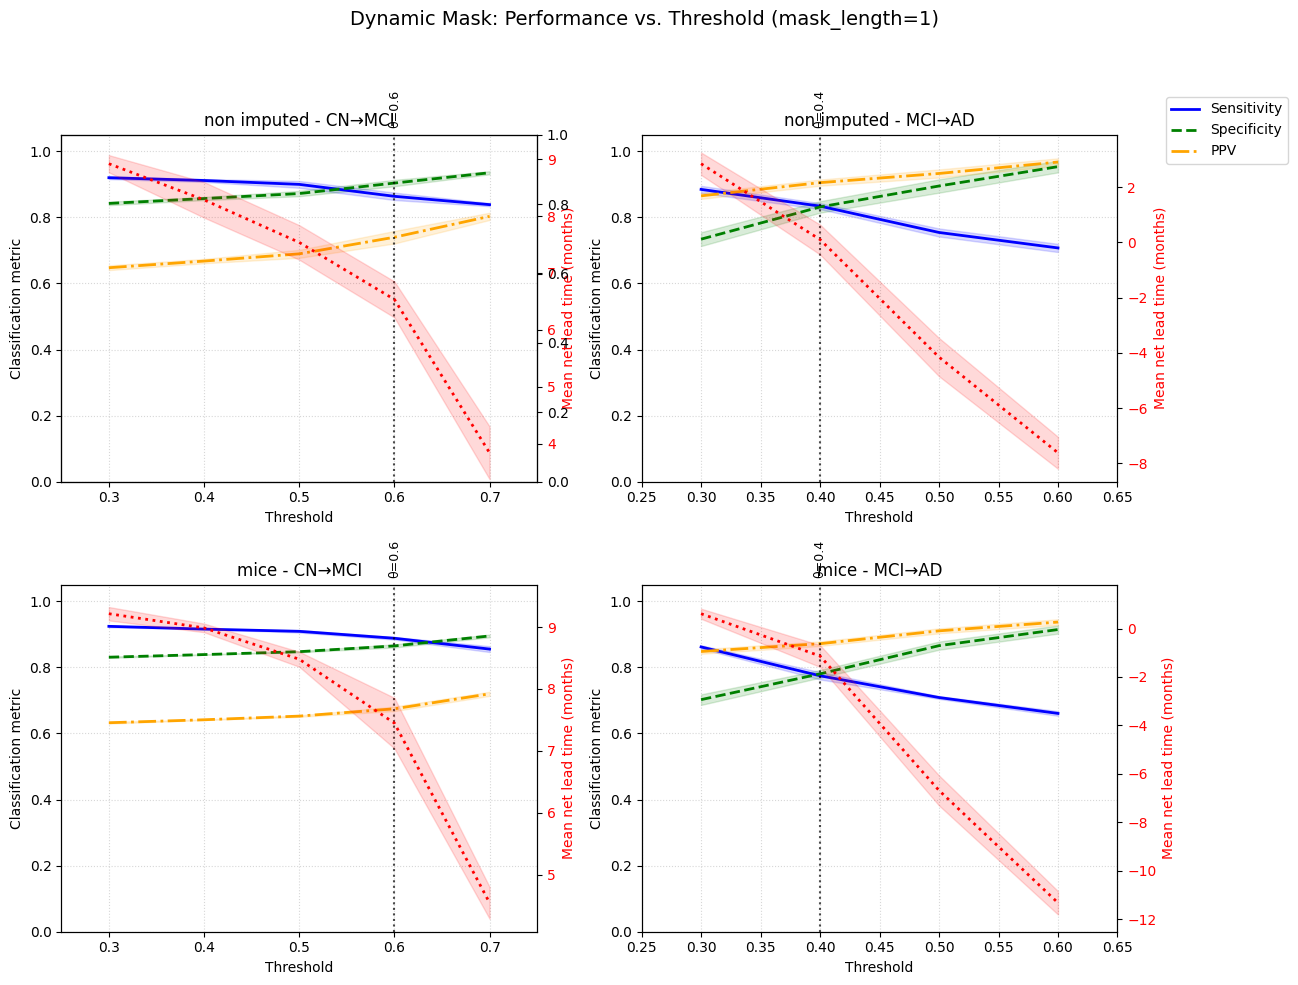

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. Load summary CSVs (same as before)
# ------------------------------------------------------------
summary_dir = Path("lead_time results")

files = {
    ("non_imputed", "CN_MCI"): "dynamic_mask_summary_non‑imputed_CN_MCI_p5.csv",
    ("non_imputed", "MCI_AD"): "dynamic_mask_summary_non‑imputed_MCI_AD_p5.csv",
    ("mice", "CN_MCI"): "dynamic_mask_summary_MICE‑imputed_CN_MCI_p5.csv",
    ("mice", "MCI_AD"): "dynamic_mask_summary_MICE‑imputed_MCI_AD_p5.csv",
}

data = {}
for (imp, cohort), fname in files.items():
    df = pd.read_csv(summary_dir / fname)
    # Keep only mask_length_mean == 1 (dominant case)
    df = df[df['mask_length_mean'] == 1.0].copy()
    data[(imp, cohort)] = df

# ------------------------------------------------------------
# 2. Updated plotting function
# ------------------------------------------------------------
def plot_metrics(data_dict, recommended=None):
    imps = ['non_imputed', 'mice']
    cohorts = ['CN_MCI', 'MCI_AD']
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=False)
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    
    # Define styles for classification metrics (primary axis)
    primary_metrics = {
        'sensitivity': {'label': 'Sensitivity', 'color': 'blue', 'linestyle': '-'},
        'specificity': {'label': 'Specificity', 'color': 'green', 'linestyle': '--'},
        'PPV': {'label': 'PPV', 'color': 'orange', 'linestyle': '-.'},
    }
    # Net lead time will be on secondary axis
    net_lead_style = {'label': 'Mean net lead time', 'color': 'red', 'linestyle': ':'}
    
    # Recommended thresholds (if not provided)
    if recommended is None:
        recommended = {
            ('non_imputed', 'CN_MCI'): 0.6,
            ('mice', 'CN_MCI'): 0.6,
            ('non_imputed', 'MCI_AD'): 0.4,
            ('mice', 'MCI_AD'): 0.4,
        }
    
    for i, imp in enumerate(imps):
        for j, cohort in enumerate(cohorts):
            ax = axes[i, j]
            df = data_dict.get((imp, cohort))
            if df is None or df.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center')
                continue
            
            df = df.sort_values('threshold')
            x = df['threshold'].values
            
            # ---- Primary axis (classification metrics) ----
            for metric, style in primary_metrics.items():
                y = df[metric + '_mean'].values
                lo = df[metric + '_ci_lower'].values
                hi = df[metric + '_ci_upper'].values
                ax.plot(x, y, label=style['label'], color=style['color'],
                        linestyle=style['linestyle'], linewidth=2)
                ax.fill_between(x, lo, hi, color=style['color'], alpha=0.15)
            
            ax.set_xlabel('Threshold', fontsize=10)
            ax.set_ylabel('Classification metric', fontsize=10, color='black')
            ax.tick_params(axis='y', labelcolor='black')
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.set_ylim(0, 1.05)   # classification metrics are 0-1
            
            # ---- Secondary axis (net lead time) ----
            ax2 = ax.twinx()
            y_net = df['mean_net_lead_time_mean'].values
            lo_net = df['mean_net_lead_time_ci_lower'].values
            hi_net = df['mean_net_lead_time_ci_upper'].values
            
            ax2.plot(x, y_net, label=net_lead_style['label'], color=net_lead_style['color'],
                     linestyle=net_lead_style['linestyle'], linewidth=2)
            ax2.fill_between(x, lo_net, hi_net, color=net_lead_style['color'], alpha=0.15)
            ax2.set_ylabel('Mean net lead time (months)', fontsize=10, color='red')
            ax2.tick_params(axis='y', labelcolor='red')
            
            # Let the secondary axis autoscale, but we can set a reasonable buffer
            y_min, y_max = y_net.min(), y_net.max()
            pad = (y_max - y_min) * 0.1 if y_max - y_min > 0 else 1
            ax2.set_ylim(y_min - pad, y_max + pad)
            
            # ---- X-axis limits based on actual data ----
            ax.set_xlim(x.min() - 0.05, x.max() + 0.05)
            
            # ---- Recommended threshold annotation ----
            rec = recommended.get((imp, cohort))
            if rec is not None and rec >= x.min() and rec <= x.max():
                ax.axvline(x=rec, color='black', linestyle=':', alpha=0.7, linewidth=1.5)
                # Place text at top of primary axis (y=1.02) to be visible
                ax.text(rec, 1.02, f'θ={rec}', rotation=90, va='bottom', ha='center',
                        fontsize=9, color='black', transform=ax.get_xaxis_transform())
            
            # ---- Title ----
            ax.set_title(f'{imp.replace("_", " ")} - {cohort.replace("_", "→")}', fontsize=12)
    
    # ---- Legend (placed outside the figure) ----
    # Collect handles from the first subplot's primary and secondary axes
    handles1, labels1 = axes[0,0].get_legend_handles_labels()
    handles2, labels2 = axes[0,0].twinx().get_legend_handles_labels()
    # Combine, avoiding duplicates
    all_handles = handles1 + handles2
    all_labels = labels1 + labels2
    fig.legend(all_handles, all_labels, loc='upper right', bbox_to_anchor=(1.0, 0.9),
               fontsize=10, frameon=True)
    
    fig.suptitle('Dynamic Mask: Performance vs. Threshold (mask_length=1)', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # make room for legend on right
    return fig

# ------------------------------------------------------------
# 3. Generate and show the plot
# ------------------------------------------------------------
fig = plot_metrics(data)
plt.show()
# Optionally save: fig.savefig('dynamic_mask_metrics_vs_threshold.png', dpi=300, bbox_inches='tight')